# データの取得

In [2]:
from google.cloud import bigquery

client = bigquery.Client(project="seikabutu-497407")

In [3]:
query = """
SELECT *
FROM mart_olist.mart_order_review
"""

df = client.query(query).to_dataframe()

df.head()

/home/kotaro/seikabutu/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,review_score,order_status,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_timestamp,customer_state,item_count,total_price,total_freight,payment_type,total_payment,main_category,delivery_days,delay_days
0,c8c528189310eaa44a745b8d9d26908b,1,canceled,NaT,2018-09-11 00:00:00+00:00,2018-08-28 20:05:14+00:00,SP,<NA>,NaN,NaN,not_defined,0.00,NaN,<NA>,<NA>
1,4637ca194b6387e2d538dc89b124b0ee,3,canceled,NaT,2018-09-10 00:00:00+00:00,2018-09-03 14:14:25+00:00,SP,<NA>,NaN,NaN,not_defined,0.00,NaN,<NA>,<NA>
2,00b1cb0320190ca0daa2c88b35206009,1,canceled,NaT,2018-09-12 00:00:00+00:00,2018-08-28 15:26:39+00:00,SP,<NA>,NaN,NaN,not_defined,0.00,NaN,<NA>,<NA>
3,baec85e7fa005a17b89b8bf93300cb5f,1,unavailable,NaT,2018-01-31 00:00:00+00:00,2018-01-12 02:07:28+00:00,SP,<NA>,NaN,NaN,voucher,16.95,NaN,<NA>,<NA>
4,7622da48f027d5659a0d7b0a43597354,1,unavailable,NaT,2017-07-21 00:00:00+00:00,2017-07-09 14:27:44+00:00,SP,<NA>,NaN,NaN,credit_card,16.97,NaN,<NA>,<NA>


# 分析対象の絞り込み

In [4]:
df_analysis =df[df["order_status"]=="delivered"].dropna(subset=["review_score"])
df_analysis.head()

,order_id,review_score,order_status,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_timestamp,customer_state,item_count,total_price,total_freight,payment_type,total_payment,main_category,delivery_days,delay_days
775,6e864b3f0ec71031117ad4cf46b7f2a1,5,delivered,2018-05-04 19:32:53+00:00,2018-05-18 00:00:00+00:00,2018-04-24 20:15:21+00:00,RJ,1,0.85,18.23,credit_card,19.08,construcao_ferramentas_construcao,9,0
776,3ee6513ae7ea23bdfab5b9ab60bffcb5,4,delivered,2018-05-07 23:21:11+00:00,2018-05-17 00:00:00+00:00,2018-04-24 11:01:06+00:00,SP,1,0.85,18.23,boleto,19.08,construcao_ferramentas_construcao,13,0
777,f1d5c2e6867fa93ceee9ef9b34a53cbf,5,delivered,2018-08-29 18:19:41+00:00,2018-09-03 00:00:00+00:00,2018-08-25 21:20:50+00:00,SP,1,2.20,7.39,voucher,9.59,beleza_saude,3,0
778,e8bbc1d69fee39eee4c72cb5c969e39d,5,delivered,2017-09-18 18:42:07+00:00,2017-09-26 00:00:00+00:00,2017-09-13 19:13:20+00:00,SP,1,2.29,7.78,credit_card,10.07,papelaria,4,0
779,38bcb524e1c38c2c1b60600a80fc8999,5,delivered,2017-01-16 16:05:22+00:00,2017-02-13 00:00:00+00:00,2017-01-05 12:06:36+00:00,PR,1,2.90,8.72,boleto,11.62,pet_shop,11,0


## ラベルの振り分け

In [5]:
df_analysis["is_low_score"] = (
    df_analysis["review_score"] <= 2
).astype(int)

## 全体の低評価率の確認

In [6]:
df_analysis["is_low_score"].mean()

np.float64(0.12806786877034812)

# 配送遅延、配送日数とレビューの関係の調査

In [7]:
df_analysis.groupby(
    "is_low_score"
)["delay_days"].describe()

,count,mean,std,min,25%,50%,75%,max
is_low_score,,,,,,,,
0,83552.0,0.228636,3.075448,0.0,0.0,0.0,0.0,162.0
1,12272.0,3.912565,9.285374,0.0,0.0,0.0,5.0,188.0


In [8]:
df_analysis.groupby(
    "is_low_score"
)["delivery_days"].describe()

,count,mean,std,min,25%,50%,75%,max
is_low_score,,,,,,,,
0,83552.0,10.922336,7.607357,0.0,6.0,9.0,14.0,194.0
1,12272.0,19.745274,15.420929,0.0,8.0,15.0,28.0,208.0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='is_low_score', ylabel='delay_days'>

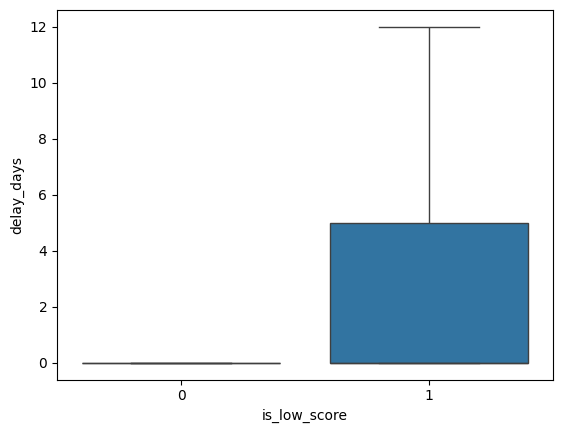

In [10]:
sns.boxplot(
    x="is_low_score",
    y="delay_days",
    data=df_analysis,
    showfliers=False
)

# 送料とレビューの関係

In [11]:
df_analysis.groupby(
    "is_low_score"
)["total_freight"].describe()

,count,mean,std,min,25%,50%,75%,max
is_low_score,,,,,,,,
0,83559.0,22.036299,20.008138,0.0,13.65,16.94,23.38,1794.96
1,12273.0,27.705419,29.381178,0.0,15.10,18.49,31.20,1002.29


<Axes: xlabel='is_low_score', ylabel='total_freight'>

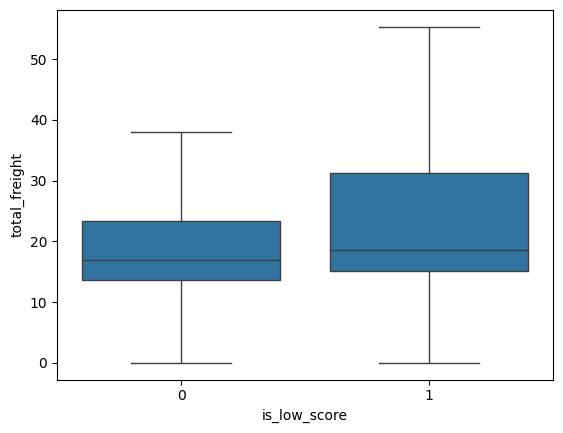

In [12]:
sns.boxplot(
    x="is_low_score",
    y="total_freight",
    data=df_analysis,
    showfliers=False
)

# 料金とレビューの関係

In [13]:
df_analysis.groupby(
    "is_low_score"
)["total_price"].describe()

,count,mean,std,min,25%,50%,75%,max
is_low_score,,,,,,,,
0,83559.0,133.411266,196.295869,0.85,45.0,84.9,149.00,6735.0
1,12273.0,159.886065,272.330394,3.54,49.9,98.0,169.99,13440.0


<Axes: xlabel='is_low_score', ylabel='total_price'>

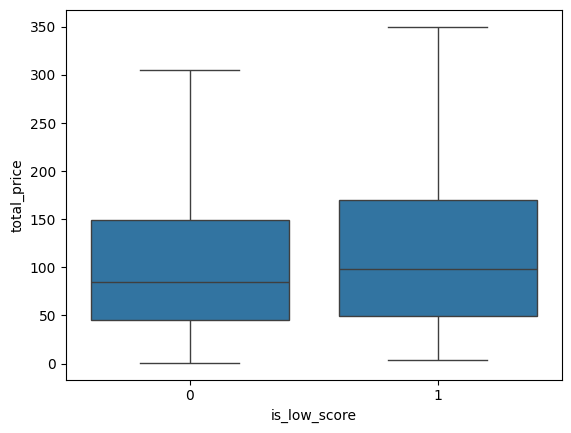

In [14]:
sns.boxplot(
    x="is_low_score",
    y="total_price",
    data=df_analysis,
    showfliers=False
)

# 支払方法とレビューの関係

In [15]:
df.groupby(
    "payment_type"
)["review_score"].mean()

payment_type
boleto         4.086627
credit_card    4.088196
debit_card     4.168968
not_defined    1.666667
voucher        4.004806
Name: review_score, dtype: Float64

In [16]:
df_analysis.groupby(
    "payment_type"
)["is_low_score"].mean()

payment_type
boleto         0.125328
credit_card    0.128826
debit_card     0.110961
voucher        0.135455
Name: is_low_score, dtype: float64

In [17]:
df[df["payment_type"]=="not_defined"].shape

(3, 15)

# 商品カテゴリーとレビューの関係

In [18]:
category_summary = (
    df_analysis
    .groupby("main_category")
    .agg(
        order_count=("order_id","count"),
        low_rate=("is_low_score","mean")
    )
)

In [19]:
category_summary[
    category_summary["order_count"] >= 100
].sort_values(
    "low_rate",
    ascending=False
)

,order_count,low_rate
main_category,,
fashion_roupa_masculina,105,0.228571
audio,345,0.217391
moveis_escritorio,1234,0.216370
casa_conforto,347,0.178674
telefonia_fixa,207,0.169082
casa_construcao,475,0.168421
fashion_underwear_e_moda_praia,116,0.163793
cama_mesa_banho,9129,0.159054
construcao_ferramentas_seguranca,154,0.155844


# 配送地域とレビューの関係

In [20]:
state_summary = (
    df_analysis
    .groupby("customer_state")
    .agg(
        order_count=("order_id","count"),
        low_rate=("is_low_score","mean")
    )
)

In [21]:
state_summary.sort_values(
    "low_rate",
    ascending=False
)

,order_count,low_rate
customer_state,,
AL,394,0.213198
MA,712,0.199438
SE,334,0.188623
RJ,12211,0.183277
PA,933,0.178992
CE,1273,0.171249
BA,3229,0.170022
PI,471,0.161359
AC,80,0.150000


# 地域差と配送遅延の関係性確認

In [22]:
state_delay = (
    df_analysis
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "count"),
        low_rate=("is_low_score", "mean"),
        avg_delay=("delay_days", "mean")
    )
)

state_delay.sort_values("low_rate", ascending=False)

,order_count,low_rate,avg_delay
customer_state,,,
AL,394,0.213198,2.015228
MA,712,0.199438,1.803371
SE,334,0.188623,2.45509
RJ,12211,0.183277,1.606257
PA,933,0.178992,1.381565
CE,1273,0.171249,2.056559
BA,3229,0.170022,1.410344
PI,471,0.161359,1.859873
AC,80,0.150000,0.7


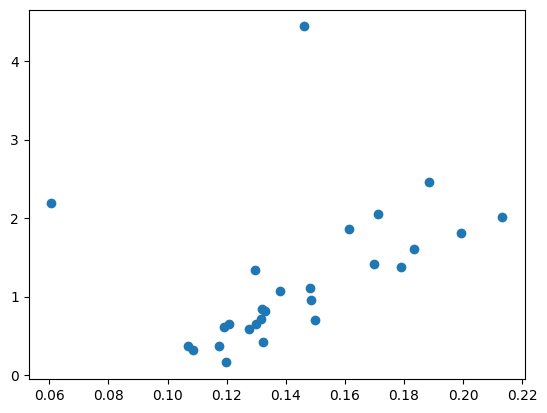

In [23]:
plt.scatter(state_delay["low_rate"], state_delay["avg_delay"])
plt.show()

In [24]:
state_delay.corr()

,order_count,low_rate,avg_delay
order_count,1.000000,-0.214470,-0.263422
low_rate,-0.214470,1.000000,0.395366
avg_delay,-0.263422,0.395366,1.000000


# カテゴリと配送遅延の関係性確認

In [25]:
category_delay = (
    df_analysis
    .groupby("main_category")
    .agg(
        order_count=("order_id", "count"),
        low_rate=("is_low_score", "mean"),
        avg_delay=("delay_days", "mean")
    )
)

category_delay[
    category_delay["order_count"] >= 100
].sort_values("low_rate", ascending=False)

,order_count,low_rate,avg_delay
main_category,,,
fashion_roupa_masculina,105,0.228571,0.428571
audio,345,0.217391,0.973913
moveis_escritorio,1234,0.216370,1.04295
casa_conforto,347,0.178674,1.368876
telefonia_fixa,207,0.169082,0.434783
casa_construcao,475,0.168421,0.770526
fashion_underwear_e_moda_praia,116,0.163793,0.793103
cama_mesa_banho,9129,0.159054,0.796582
construcao_ferramentas_seguranca,154,0.155844,0.37013


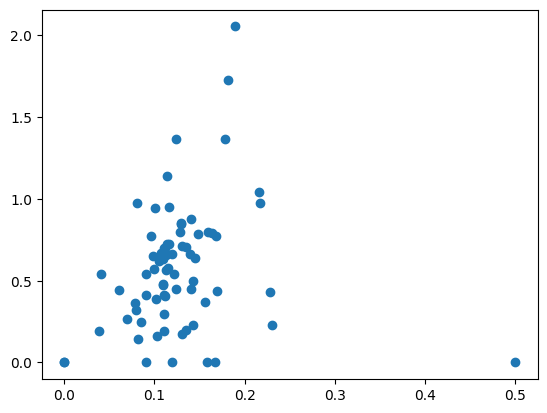

In [26]:
plt.scatter(category_delay["low_rate"], category_delay["avg_delay"])
plt.show()

In [27]:
category_delay.corr()

,order_count,low_rate,avg_delay
order_count,1.000000,0.011256,0.194855
low_rate,0.011256,1.000000,0.144440
avg_delay,0.194855,0.144440,1.000000


In [28]:
df_analysis.groupby("is_low_score")[
    ["delivery_days", "delay_days", "total_price", "total_freight"]
].mean()

,delivery_days,delay_days,total_price,total_freight
is_low_score,,,,
0,10.922336,0.228636,133.411266,22.036299
1,19.745274,3.912565,159.886065,27.705419


In [29]:
# 高低評価カテゴリの注文数確認
category_summary.sort_values(
    ["low_rate", "order_count"],
    ascending=[False, False]
).head(10)

# 高低評価地域の注文数確認
state_summary.sort_values(
    ["low_rate", "order_count"],
    ascending=[False, False]
).head(10)

,order_count,low_rate
customer_state,,
AL,394,0.213198
MA,712,0.199438
SE,334,0.188623
RJ,12211,0.183277
PA,933,0.178992
CE,1273,0.171249
BA,3229,0.170022
PI,471,0.161359
AC,80,0.150000


In [35]:
state_summary = df_analysis.groupby("customer_state").agg(
    order_count=("order_id","count"),
    low_rate=("is_low_score","mean"),
    avg_delay=("delay_days","mean"),
    avg_delivery=("delivery_days","mean"),
    avg_freight=("total_freight","mean")
).sort_values(
    "low_rate",
    ascending=False
)
state_summary

,order_count,low_rate,avg_delay,avg_delivery,avg_freight
customer_state,,,,,
AL,394,0.213198,2.015228,23.956853,38.580279
MA,712,0.199438,1.803371,20.985955,42.946503
SE,334,0.188623,2.45509,20.949102,40.316946
RJ,12211,0.183277,1.606257,14.781263,23.916474
PA,933,0.178992,1.381565,23.18328,39.482862
CE,1273,0.171249,2.056559,20.756481,36.515334
BA,3229,0.170022,1.410344,18.77733,29.966717
PI,471,0.161359,1.859873,19.031847,43.054628
AC,80,0.150000,0.7,20.6375,45.554500


In [36]:
state_summary[[
    "low_rate",
    "avg_delay",
    "avg_delivery",
    "avg_freight"
]].corr()

,low_rate,avg_delay,avg_delivery,avg_freight
low_rate,1.000000,0.395366,0.275281,0.247382
avg_delay,0.395366,1.000000,0.712772,0.481913
avg_delivery,0.275281,0.712772,1.000000,0.801304
avg_freight,0.247382,0.481913,0.801304,1.000000
